In [1]:
import pandas as pd
import random

In [2]:
L = []

for i in range(10000):
    L.append(random.randint(1,6))

In [3]:
len(L)

10000

In [4]:
L[:5]

[1, 2, 2, 4, 3]

In [8]:
pd.Series(L).value_counts()

1    1706
2    1690
5    1684
3    1681
6    1627
4    1612
Name: count, dtype: int64

In [32]:
print(pd.Series(L).value_counts().sum())

pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()

10000


1    0.1706
2    0.1690
5    0.1684
3    0.1681
6    0.1627
4    0.1612
Name: count, dtype: float64

In [33]:
s = (pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()).sort_index()

In [34]:
s

1    0.1706
2    0.1690
3    0.1681
4    0.1612
5    0.1684
6    0.1627
Name: count, dtype: float64

<Axes: >

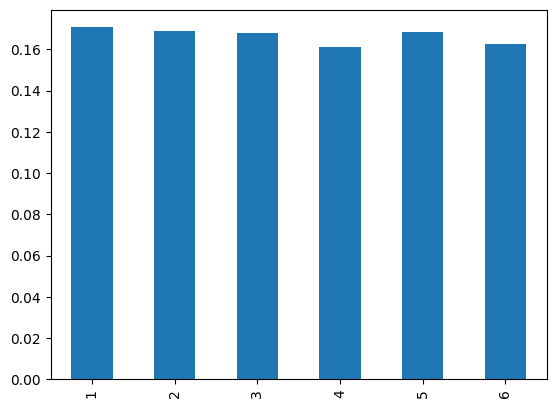

In [35]:
s.plot(kind='bar')

In [38]:
# 2 dice roll

L = []
for i in range(10000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    L.append(a+b)

In [39]:
L[:5]

[4, 10, 9, 6, 5]

In [43]:
pd.Series(L).value_counts().sort_index()

2      296
3      545
4      912
5     1092
6     1446
7     1603
8     1322
9     1164
10     798
11     528
12     294
Name: count, dtype: int64

In [44]:
s = (pd.Series(L).value_counts() / pd.Series(L).value_counts().sum()).sort_index()
s

2     0.0296
3     0.0545
4     0.0912
5     0.1092
6     0.1446
7     0.1603
8     0.1322
9     0.1164
10    0.0798
11    0.0528
12    0.0294
Name: count, dtype: float64

<Axes: >

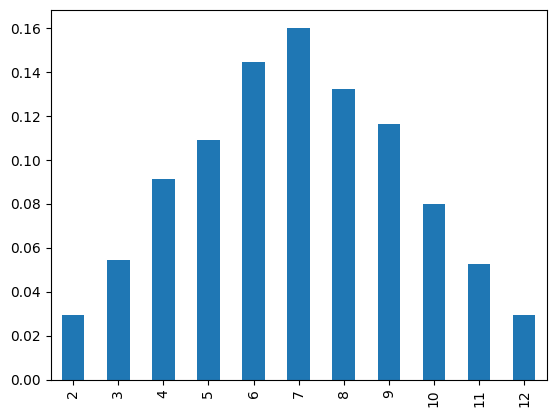

In [45]:
s.plot(kind='bar')

In [51]:
# s.plot(kind='pie')

In [48]:
import numpy as np
np.cumsum(s)

2     0.0296
3     0.0841
4     0.1753
5     0.2845
6     0.4291
7     0.5894
8     0.7216
9     0.8380
10    0.9178
11    0.9706
12    1.0000
Name: count, dtype: float64

<Axes: >

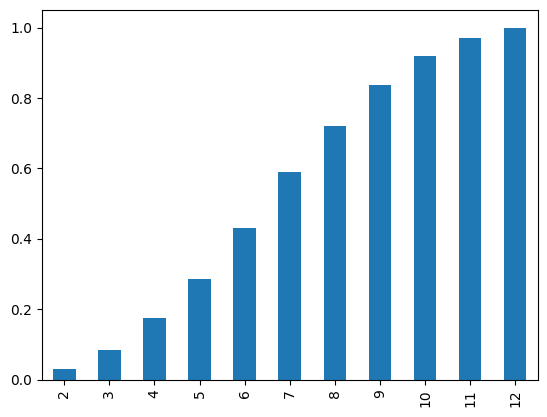

In [50]:
np.cumsum(s).plot(kind='bar')

### Parameteic Density Estimation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import normal

In [4]:
sample = normal(loc=50, scale=5, size=1000)
sample

array([45.44618727, 46.46825292, 45.87049877, 53.94339102, 47.67555145,
       42.60545906, 51.0865864 , 39.87947895, 54.26484961, 50.27642681,
       39.43189531, 51.03828965, 43.38350909, 57.62533367, 50.20770008,
       49.36173713, 44.60860569, 49.47467621, 45.92184973, 47.81039705,
       54.47059228, 53.21507092, 51.10605452, 46.63796369, 50.86647608,
       54.94593896, 44.5619134 , 52.76563274, 59.77362018, 55.76937039,
       54.83953038, 55.69463124, 51.96209442, 48.27216835, 49.13888227,
       52.84436978, 58.05245493, 51.6019525 , 42.9262601 , 53.22404687,
       48.35630905, 50.98446581, 48.65566585, 55.35527176, 48.032592  ,
       49.86038408, 51.03871875, 49.38514004, 51.85173902, 50.85227668,
       59.42030598, 48.27632792, 55.97535425, 52.89809823, 49.08385808,
       53.91085063, 43.56406626, 50.54260686, 51.35111703, 51.22858075,
       50.90519927, 51.01251889, 55.02053636, 45.23698872, 52.50823144,
       43.98498487, 52.23551614, 53.73739576, 52.90999828, 61.18

In [5]:
sample.mean()

np.float64(50.10997259440785)

In [6]:
sample.std()

np.float64(4.948032010725807)

(array([  6.,  23.,  86., 193., 243., 251., 137.,  52.,   6.,   3.]),
 array([34.00578969, 37.38499441, 40.76419914, 44.14340386, 47.52260859,
        50.90181332, 54.28101804, 57.66022277, 61.03942749, 64.41863222,
        67.79783694]),
 <BarContainer object of 10 artists>)

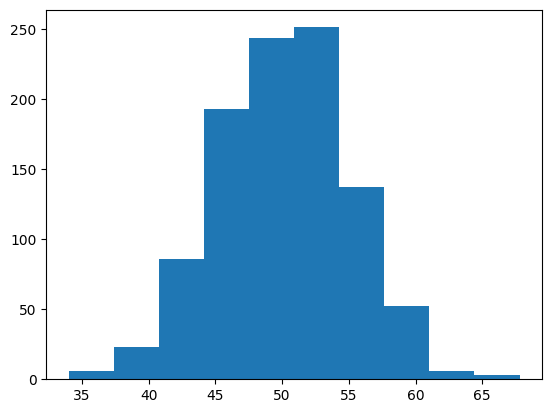

In [10]:
plt.hist(sample, bins=10)

In [11]:
sample_meam = sample.mean()
sample_std = sample.std()

In [38]:
# fit the distribution with the above parameter
from scipy.stats import norm
dist = norm(sample_meam, sample_std) # based on close to mean and std graph depends
dist

In [17]:
values = np.linspace(sample.min(), sample.max(), 100)

In [20]:
probabilities_density = [dist.pdf(value) for value in values]

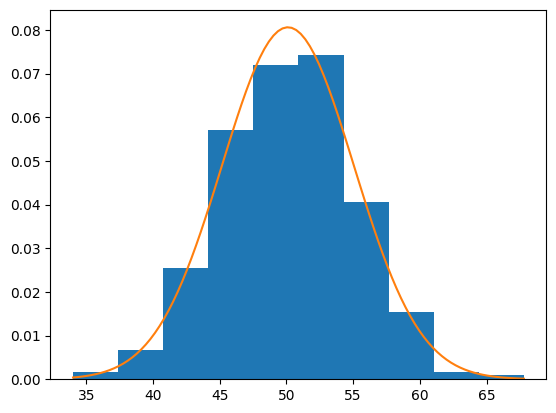

In [37]:
plt.hist(sample, bins=10, density=True)
plt.plot(values, probabilities_density)
# here the graph is depend on two things: mean and STD

C:\Temp\ipykernel_23540\1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

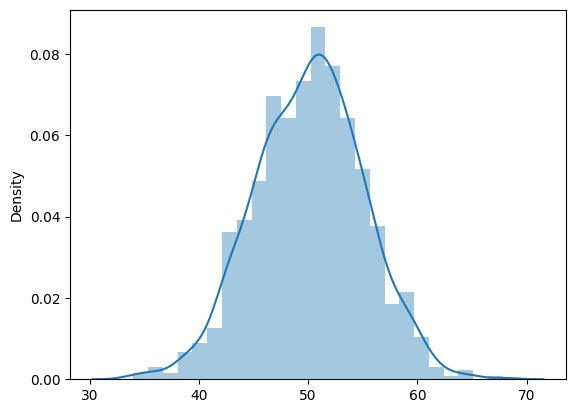

In [35]:
import seaborn as sns
sns.distplot(sample)